In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from scipy.linalg import svd
from scipy.spatial import distance
from sklearn.preprocessing import normalize

In [ ]:
def get_data(n_samples, seed):
    T_matrix = [[-0.60834549, -0.63667341], [0.40887718, 0.85253229]]
    X_orig, y_orig = make_blobs(n_samples=n_samples, random_state=170)
    X = np.dot(X_orig, T_matrix)
    return X

In [ ]:
def show_data_results(X, y_pred=None, cmap='jet'):
    if y_pred is None:
        plt.scatter(X[:, 0], X[:, 1])
        plt.title ("input data")
    else:
        fig = plt.figure(figsize=(10, 3))
        ax1 = fig.add_subplot(121)
        ax1.scatter(X[:, 0], X[:, 1])
        ax1.set(xticks=[],yticks=[],title ="input data")

        ax2 = fig.add_subplot(122)
        ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap=cmap)
        ax2.set(xticks=[], yticks=[], title ="clustered data")

In [ ]:
n_samples, seed = 2000, 170
X = get_data(n_samples, seed)

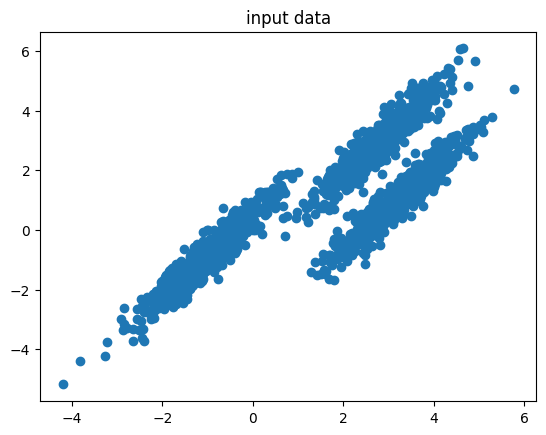

In [ ]:
show_data_results(X)

In [ ]:
from scipy.spatial import distance

def get_adjacency_matrix(gamma, X):
    squared_distances = distance.cdist(X, X, 'sqeuclidean')
    adjacency_matrix = np.exp(gamma * squared_distances)
    return adjacency_matrix


In [ ]:
def get_degree_matrix(adjacency_matrix):
    row_sums = np.sum(adjacency_matrix, axis=1)
    inverse_sqrt_degrees = 1.0 / np.sqrt(row_sums)
    degree_matrix_inv_sqrt = np.diag(inverse_sqrt_degrees)
    return degree_matrix_inv_sqrt


In [ ]:

n_samples, seed = 2000, 170
X = get_data(n_samples, seed)
gamma_value = 7.5

adjacency_matrix = get_adjacency_matrix(gamma_value, X)
print("Adjacency Matrix (A) shape:", adjacency_matrix.shape)

degree_matrix_inv_sqrt = get_degree_matrix(adjacency_matrix)
print("Inverse Square Root of Degree Matrix (D^(-1/2)) shape:", degree_matrix_inv_sqrt.shape)

M = np.dot(np.dot(degree_matrix_inv_sqrt, adjacency_matrix), degree_matrix_inv_sqrt)
print("Symmetrically Normalized Adjacency Matrix (M) shape:", M.shape)


/tmp/ipython-input-6-4239961317.py:5: RuntimeWarning: overflow encountered in exp
  adjacency_matrix = np.exp(gamma * squared_distances)


Adjacency Matrix (A) shape: (2000, 2000)
Inverse Square Root of Degree Matrix (D^(-1/2)) shape: (2000, 2000)
Symmetrically Normalized Adjacency Matrix (M) shape: (2000, 2000)


Stochastic Matrix (M_stoch) shape: (2000, 2000)
Shape of U vectors used for KMeans: (2000, 3)
Shape of predicted cluster labels: (2000,)


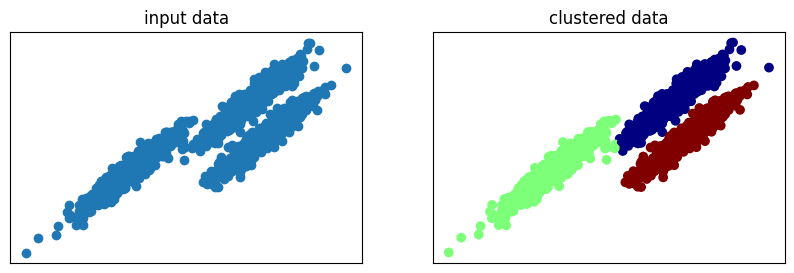

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import normalize

def get_data(n_samples, seed):
    T_matrix = [[-0.60834549, -0.63667341], [0.40887718, 0.85253229]]
    X_orig, y_orig = make_blobs(n_samples=n_samples, random_state=170)
    X = np.dot(X_orig, T_matrix)
    return X

def show_data_results(X, y_pred=None, cmap='jet'):
    if y_pred is None:
        plt.scatter(X[:, 0], X[:, 1])
        plt.title ("input data")
    else:
        fig = plt.figure(figsize=(10, 3))
        ax1 = fig.add_subplot(121)
        ax1.scatter(X[:, 0], X[:, 1])
        ax1.set(xticks=[],yticks=[],title ="input data")

        ax2 = fig.add_subplot(122)
        ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap=cmap)
        ax2.set(xticks=[], yticks=[], title ="clustered data")
    plt.show()

def get_adjacency_matrix(gamma, X):
    squared_distances = distance.cdist(X, X, 'sqeuclidean')
    adjacency_matrix = np.exp(-gamma * squared_distances)
    return adjacency_matrix

def get_degree_matrix(adjacency_matrix):
    row_sums = np.sum(adjacency_matrix, axis=1)
    row_sums[row_sums == 0] = 1e-10
    inverse_sqrt_degrees = 1.0 / np.sqrt(row_sums)
    degree_matrix_inv_sqrt = np.diag(inverse_sqrt_degrees)
    return degree_matrix_inv_sqrt

def stochastic_matrix_converter(M):
    column_sums = np.sum(M, axis=0)
    column_sums[column_sums == 0] = 1.0
    M_stoch = M / column_sums
    return M_stoch

def cluster_data(M_stoch, n_clusters=3):
    eigenvalues, eigenvectors = np.linalg.eig(M_stoch)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    U = np.real(eigenvectors[:, sorted_indices[:n_clusters]])
    U_normalized = normalize(U, axis=1, norm='l2')
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    y_pred = kmeans.fit_predict(U_normalized)
    return U_normalized, y_pred

n_samples, seed = 2000, 170
X = get_data(n_samples, seed)

gamma_value = 7.5

adjacency_matrix = get_adjacency_matrix(gamma_value, X)
degree_matrix_inv_sqrt = get_degree_matrix(adjacency_matrix)
M = np.dot(np.dot(degree_matrix_inv_sqrt, adjacency_matrix), degree_matrix_inv_sqrt)

M_stoch = stochastic_matrix_converter(M)
print("Stochastic Matrix (M_stoch) shape:", M_stoch.shape)

U_vectors, y_pred_spectral_stoch = cluster_data(M_stoch, n_clusters=3)
print("Shape of U vectors used for KMeans:", U_vectors.shape)
print("Shape of predicted cluster labels:", y_pred_spectral_stoch.shape)

show_data_results(X, y_pred_spectral_stoch)
